In [14]:
pip install pytrends

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq

# setup pytrend library and keyword define

In [34]:
pytrends =TrendReq(hl ='en-us', tz=360)
keywords="Cloud Computing"

# Data Request

In [35]:
pytrends.build_payload([keywords], cat=0, timeframe='today 12-m',geo='', gprop='')

# country wise interest

In [23]:
region_data = pytrends.interest_by_region()
region_data = region_data.sort_values(by=keywords, ascending=False).head(20)

C:\Users\krush\AppData\Local\Temp\ipykernel_3792\250231499.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




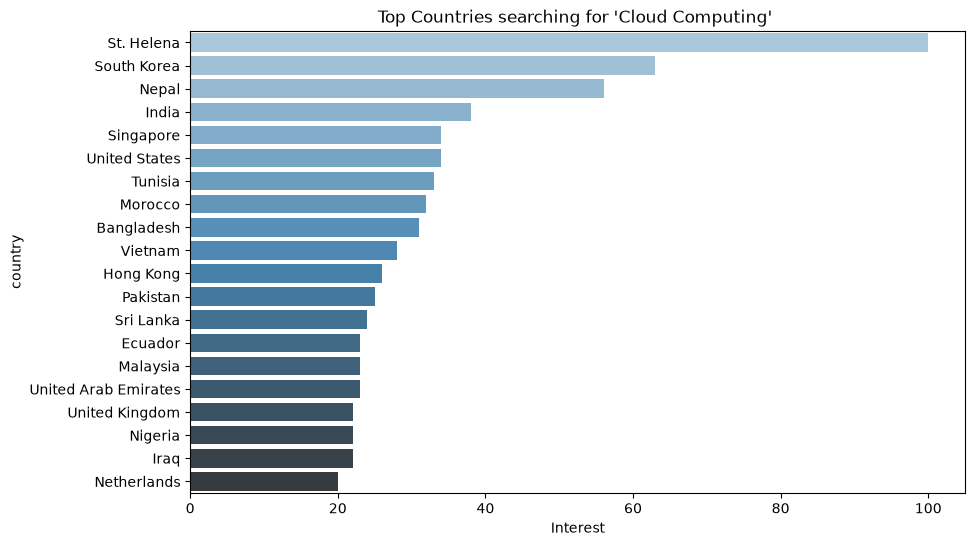

In [25]:
plt.figure(figsize = (10,6))
sns.barplot(x= region_data[keywords], y = region_data.index, palette='Blues_d')
plt.title(f"Top Countries searching for '{keywords}' ")
plt.xlabel("Interest")
plt.ylabel("country")
plt.show()

# world map

C:\Users\krush\AppData\Local\Temp\ipykernel_3792\141769660.py:5: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



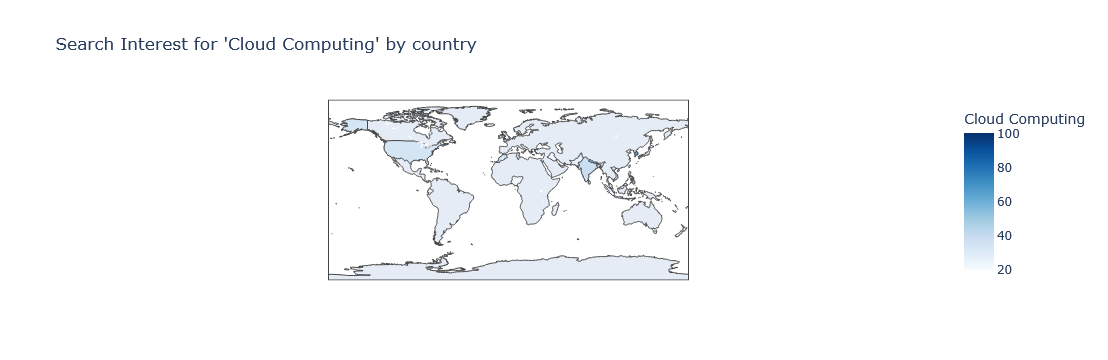

In [28]:
#import plotly.express as px
region_data = region_data.reset_index()

fig = px.choropleth(
    region_data,
    locations='geoName',
    locationmode='country names',
    color=keywords,
    title=f"Search Interest for '{keywords}' by country",
    color_continuous_scale='Blues')

fig.show()

# time wise interest

C:\Users\krush\AppData\Roaming\Python\Python313\site-packages\pytrends\request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



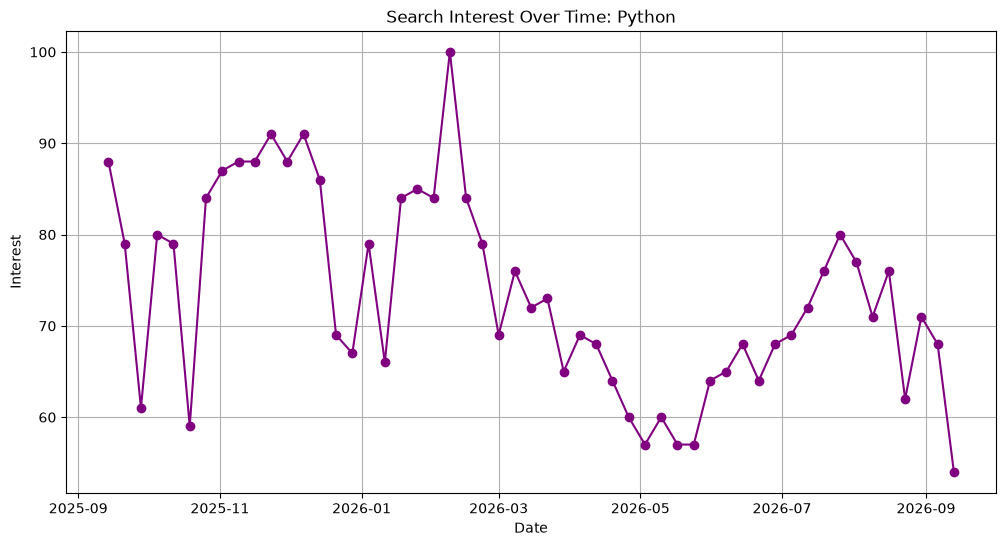

In [31]:
from pytrends.request import TrendReq
import matplotlib.pyplot as plt

pytrends = TrendReq(hl='en-US', tz=360, timeout=(10, 30))

keyword = "Python"
pytrends.build_payload([keyword], timeframe='today 12-m', geo='IN')

time_df = pytrends.interest_over_time()

col = [c for c in time_df.columns if c != 'isPartial'][0]

plt.figure(figsize=(12, 6))
plt.plot(time_df.index, time_df[col], marker='o', color='purple')
plt.title(f"Search Interest Over Time: {col}")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.grid(True)
plt.show()

Index(['Cloud Computing', 'isPartial'], dtype='object')
(53, 2)


C:\Users\krush\AppData\Roaming\Python\Python313\site-packages\pytrends\request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



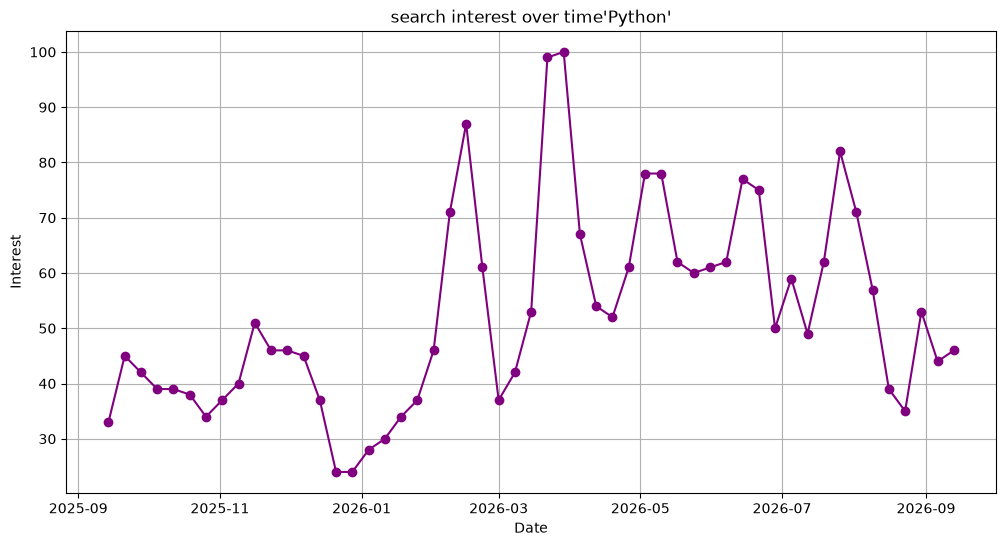

In [40]:
from pytrends.request import TrendReq

print(time_df.columns)
print(time_df.shape)
time_df=pytrends.interest_over_time()
plt.figure(figsize=(12,6))
#plt.plot(time_df.index, time_df[keyword], marker='o', color='purple')
plt.plot(time_df.index, time_df.iloc[:, 0], marker='o', color='purple')

plt.title(f"search interest over time'{keyword}'")
plt.xlabel('Date')
plt.ylabel("Interest")
plt.grid(True)
plt.show()


# multiple keywords compare

In [41]:
kw_list=["cloud computing","data science","machin learning","artificial inteligens"]
pytrends.build_payload(kw_list, cat=0, timeframe='today 12-m', geo='', gprop='')

C:\Users\krush\AppData\Roaming\Python\Python313\site-packages\pytrends\request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



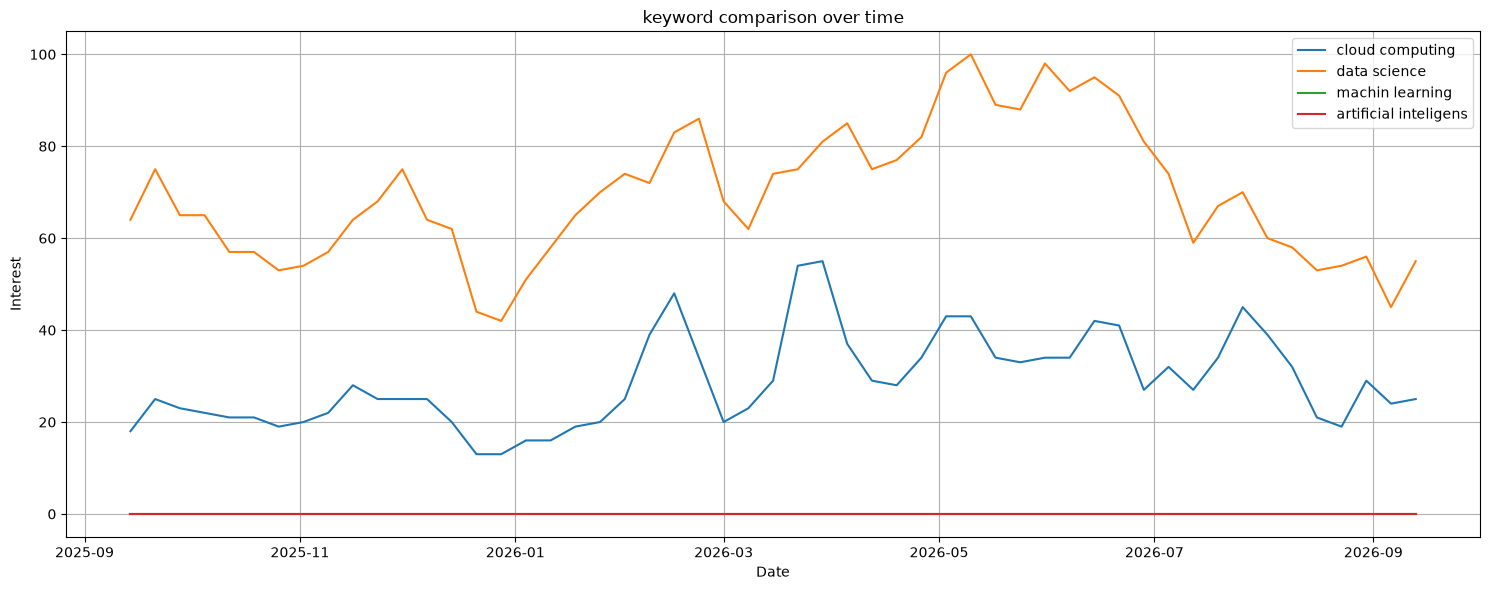

In [42]:
compare_df=pytrends.interest_over_time()

plt.figure(figsize=(15,6))
for kw in kw_list:
    plt.plot(compare_df.index, compare_df[kw], label=kw)

plt.title("keyword comparison over time")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()